# Practical Incremental SfM khi không có ma trận K và R

In [1]:
from __future__ import annotations

import os
import math
import zipfile
import urllib.request
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import least_squares

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except Exception:
    PLOTLY_AVAILABLE = False

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"
np.set_printoptions(suppress=True, precision=4)


In [ ]:
# =========================================================
# CONFIG
# =========================================================
RNG = np.random.default_rng(42)

DATA_ROOT = Path("data")
SCENE_NAME = "dinoRing"
ZIP_URL = "https://vision.middlebury.edu/mview/data/data/dinoRing.zip"
OUTPUT_ROOT = Path("outputs_dinoRing_sfm_unknown_K_pose")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MAX_IMAGES = None

# Feature extraction
SIFT_NFEATURES = 12000
SIFT_CONTRAST_THRESHOLD = 0.01
SIFT_EDGE_THRESHOLD = 25
SIFT_SIGMA = 1.2

# Pair matching
PAIR_MODE = "all"        
PAIR_OFFSETS = [1, 2, 3, 4, 5, 6, 8]
MIN_RAW_MATCHES = 30
RATIO_TEST = 0.80

# Fundamental matrix / initial geometry
F_RANSAC_THRESH = 1.5
F_RANSAC_CONF = 0.999
MIN_F_INLIERS = 40

INIT_FOCAL_RATIO = 1.2   # f ~= 1.2 * max(H, W)

# Triangulation / reprojection
MIN_TRACK_LENGTH_FOR_POINT = 2
MIN_TRI_ANGLE_DEG = 0.5
POINT_REPROJ_THRESH = 3.0
MAX_POINT_REPROJ_THRESH = 5.0
POINT_REFINE_MAX_NFEV = 50

# PnP registration
MIN_PNP_POINTS = 8
MIN_PNP_INLIERS = 20
PNP_REPROJ_THRESH = 4.0

# Bundle adjustment
RUN_BUNDLE_ADJUSTMENT = True
BA_MAX_NFEV = 60
BA_FOCAL_MIN_RATIO = 0.5
BA_FOCAL_MAX_RATIO = 3.0

# Plotting
PLOT_MAX_POINTS = 30000
SHOW_PLOTS = True
SAVE_INTERACTIVE_HTML = True
MATPLOTLIB_POINT_SIZE = 5
PLOTLY_POINT_SIZE = 2.6


In [3]:
VALID_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".ppm", ".pgm"}

def ensure_dir(path: os.PathLike):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def normalize_rows(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    if len(x) == 0:
        return x.copy()
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

def to_h(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x)
    return np.hstack([x, np.ones((len(x), 1), dtype=x.dtype)])

def from_h(xh: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    xh = np.asarray(xh)
    return xh[:, :-1] / (xh[:, -1:] + eps)

def skew(v: np.ndarray) -> np.ndarray:
    v = np.asarray(v, dtype=np.float64).reshape(3)
    return np.array([
        [0.0, -v[2],  v[1]],
        [v[2],  0.0, -v[0]],
        [-v[1], v[0], 0.0],
    ], dtype=np.float64)

def project_points(X: np.ndarray, K: np.ndarray, R: np.ndarray, t: np.ndarray):
    X = np.asarray(X, dtype=np.float64).reshape(-1, 3)
    R = np.asarray(R, dtype=np.float64).reshape(3, 3)
    t = np.asarray(t, dtype=np.float64).reshape(3, 1)
    Xc = (R @ X.T + t).T
    z = Xc[:, 2].copy()
    x = (K @ Xc.T).T
    uv = x[:, :2] / (x[:, 2:3] + 1e-12)
    return uv, z

def camera_center_from_pose(R: np.ndarray, t: np.ndarray) -> np.ndarray:
    R = np.asarray(R, dtype=np.float64).reshape(3, 3)
    t = np.asarray(t, dtype=np.float64).reshape(3)
    return -R.T @ t

def camera_view_direction_world(R: np.ndarray) -> np.ndarray:
    d = np.asarray(R, dtype=np.float64).T @ np.array([0.0, 0.0, 1.0], dtype=np.float64)
    return d / (np.linalg.norm(d) + 1e-12)

def sample_point_color(img_rgb: np.ndarray, uv: np.ndarray) -> np.ndarray:
    h, w = img_rgb.shape[:2]
    x = int(np.clip(round(float(uv[0])), 0, w - 1))
    y = int(np.clip(round(float(uv[1])), 0, h - 1))
    return img_rgb[y, x]

def robust_subsample_indices(n: int, max_n: int) -> np.ndarray:
    if n <= max_n:
        return np.arange(n)
    return np.linspace(0, n - 1, max_n).astype(int)

def set_axes_equal_3d(ax, xyz: np.ndarray):
    xyz = np.asarray(xyz, dtype=np.float64)
    if xyz.size == 0:
        return
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = 0.5 * np.max(maxs - mins)
    radius = max(radius, 1e-3)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

def scene_radius(xyz: np.ndarray) -> float:
    xyz = np.asarray(xyz, dtype=np.float64)
    if xyz.size == 0:
        return 1.0
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    return float(max(0.5 * np.max(maxs - mins), 1e-3))


In [4]:
def find_image_root(search_root: Path) -> Path:
    search_root = Path(search_root)
    counts = defaultdict(int)
    for p in search_root.rglob("*"):
        if p.is_file() and p.suffix.lower() in VALID_EXTS:
            counts[p.parent] += 1
    if not counts:
        raise FileNotFoundError(f"Không tìm thấy ảnh trong {search_root.resolve()}")
    return max(counts.items(), key=lambda kv: kv[1])[0]

def download_and_extract_dino_ring(
    zip_url: str = ZIP_URL,
    data_root: Path = DATA_ROOT,
    scene_name: str = SCENE_NAME,
) -> Path:
    data_root = ensure_dir(data_root)
    zip_path = data_root / f"{scene_name}.zip"

    try:
        image_root = find_image_root(data_root)
        print(f"[INFO] Using existing extracted images at: {image_root}")
        return image_root
    except FileNotFoundError:
        pass

    if not zip_path.exists():
        print(f"[INFO] Downloading dataset to: {zip_path}")
        urllib.request.urlretrieve(zip_url, zip_path)
    else:
        print(f"[INFO] Found existing zip: {zip_path}")

    print(f"[INFO] Extracting zip to: {data_root}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(data_root)

    image_root = find_image_root(data_root)
    print(f"[INFO] Image root found at: {image_root}")
    return image_root

def load_scene_without_calibration(scene_root: Path, max_images=None):
    scene_root = Path(scene_root)
    image_paths = sorted([p for p in scene_root.rglob("*") if p.suffix.lower() in VALID_EXTS])

    if not image_paths:
        raise FileNotFoundError(f"Không có ảnh trong {scene_root.resolve()}")

    if max_images is not None:
        image_paths = image_paths[:max_images]

    images_rgb, gray_images, kept_paths = [], [], []
    for img_path in image_paths:
        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img is None:
            continue
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        images_rgb.append(rgb)
        gray_images.append(gray)
        kept_paths.append(img_path)

    if not images_rgb:
        raise RuntimeError("Không load được ảnh nào.")

    return {
        "scene_root": scene_root,
        "images_rgb": images_rgb,
        "gray_images": gray_images,
        "image_paths": kept_paths,
        "image_names": [p.name for p in kept_paths],
    }


In [5]:
def compute_rootsift(gray: np.ndarray, nfeatures: int = 5000):
    sift = cv2.SIFT_create(
        nfeatures=nfeatures,
        contrastThreshold=SIFT_CONTRAST_THRESHOLD,
        edgeThreshold=SIFT_EDGE_THRESHOLD,
        sigma=SIFT_SIGMA,
    )
    kps, desc = sift.detectAndCompute(gray, None)
    if desc is None or len(kps) == 0:
        return [], np.zeros((0, 128), dtype=np.float32), np.zeros((0, 2), dtype=np.float32)

    desc = desc.astype(np.float32)
    desc /= (np.sum(desc, axis=1, keepdims=True) + 1e-12)
    desc = np.sqrt(desc)
    pts = np.array([kp.pt for kp in kps], dtype=np.float32)
    return kps, desc, pts

def extract_all_features(gray_images, nfeatures=SIFT_NFEATURES):
    feats = []
    counts = []
    for gray in tqdm(gray_images, desc="Extract RootSIFT"):
        kps_cv, desc, pts = compute_rootsift(gray, nfeatures=nfeatures)
        feats.append({"kps_cv": kps_cv, "desc": desc, "pts": pts})
        counts.append(len(pts))
    counts = np.asarray(counts, dtype=np.int32)
    if len(counts):
        print(
            "Feature count stats | "
            f"min={counts.min()} | median={int(np.median(counts))} | max={counts.max()}"
        )
    return feats

def match_descriptors_mutual(desc1: np.ndarray, desc2: np.ndarray, ratio: float = 0.75):
    if len(desc1) == 0 or len(desc2) == 0:
        return np.zeros((0, 2), dtype=np.int32)

    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    knn12 = bf.knnMatch(desc1, desc2, k=2)
    knn21 = bf.knnMatch(desc2, desc1, k=2)

    good12 = {}
    for pair in knn12:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < ratio * n.distance:
            good12[m.queryIdx] = m.trainIdx

    good21 = {}
    for pair in knn21:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < ratio * n.distance:
            good21[m.queryIdx] = m.trainIdx

    mutual = []
    for q1, t1 in good12.items():
        if t1 in good21 and good21[t1] == q1:
            mutual.append((q1, t1))

    if not mutual:
        return np.zeros((0, 2), dtype=np.int32)
    return np.asarray(sorted(set(mutual)), dtype=np.int32)

def build_candidate_pairs(n_images: int, mode: str = "all", offsets=None):
    if mode == "all":
        return [(i, j) for i in range(n_images) for j in range(i + 1, n_images)]
    if mode == "ring":
        pairs = set()
        offsets = [1, 2, 3, 4] if offsets is None else list(offsets)
        for i in range(n_images):
            for off in offsets:
                j = (i + off) % n_images
                if i == j:
                    continue
                a, b = min(i, j), max(i, j)
                pairs.add((a, b))
        return sorted(pairs)
    raise ValueError(f"Unknown pair mode: {mode}")


Ta ước lượng **Fundamental matrix** bằng RANSAC:

\[
x_2^T F x_1 = 0
\]

Sau đó khởi tạo một \(K\) gần đúng từ kích thước ảnh:

\[
K =
\begin{bmatrix}
f & 0 & c_x \\
0 & f & c_y \\
0 & 0 & 1
\end{bmatrix}
\]

với:

\[
f \approx \alpha \cdot \max(H,W)
\]

Rồi suy ra:

\[
E = K^T F K
\]

và dùng `recoverPose` để lấy pose tương đối.


In [6]:
def estimate_fundamental_ransac(pts1: np.ndarray, pts2: np.ndarray,
                                thresh: float = F_RANSAC_THRESH,
                                conf: float = F_RANSAC_CONF):
    if len(pts1) < 8 or len(pts2) < 8:
        return None, np.zeros((0,), dtype=bool)

    F, mask = cv2.findFundamentalMat(
        pts1.astype(np.float32),
        pts2.astype(np.float32),
        method=cv2.FM_RANSAC,
        ransacReprojThreshold=thresh,
        confidence=conf,
    )

    if F is None or mask is None:
        return None, np.zeros((len(pts1),), dtype=bool)

    F = np.asarray(F, dtype=np.float64)
    if F.ndim == 3:
        F = F[0]
    if F.shape != (3, 3):
        F = F[:3, :3]

    mask = mask.ravel().astype(bool)
    return F, mask

def compute_pairwise_geometry(feats, n_images):
    candidate_pairs = build_candidate_pairs(n_images, mode=PAIR_MODE, offsets=PAIR_OFFSETS)

    pair_results = {}
    pair_inliers = {}
    image_pair_counts = defaultdict(int)

    for (i, j) in tqdm(candidate_pairs, desc="Pair matching + F-RANSAC"):
        matches = match_descriptors_mutual(feats[i]["desc"], feats[j]["desc"], ratio=RATIO_TEST)
        if len(matches) < MIN_RAW_MATCHES:
            continue

        p1 = feats[i]["pts"][matches[:, 0]]
        p2 = feats[j]["pts"][matches[:, 1]]

        F, mask = estimate_fundamental_ransac(p1, p2)
        if F is None:
            continue

        inlier_matches = matches[mask]
        if len(inlier_matches) < MIN_F_INLIERS:
            continue

        pair_results[(i, j)] = {
            "raw_matches": matches,
            "inlier_matches": inlier_matches,
            "n_raw": len(matches),
            "n_inliers": len(inlier_matches),
            "F": F,
        }
        pair_inliers[(i, j)] = inlier_matches
        image_pair_counts[i] += 1
        image_pair_counts[j] += 1

    return pair_results, pair_inliers, image_pair_counts

def init_intrinsics_from_image_shape(image_shape, focal_ratio: float = INIT_FOCAL_RATIO):
    h, w = image_shape[:2]
    f = focal_ratio * max(h, w)
    cx = 0.5 * w
    cy = 0.5 * h
    K = np.array([
        [f, 0.0, cx],
        [0.0, f, cy],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)
    return K

def essential_from_fundamental(F: np.ndarray, K: np.ndarray):
    E = K.T @ F @ K
    U, _, Vt = np.linalg.svd(E)
    if np.linalg.det(U) < 0:
        U[:, -1] *= -1
    if np.linalg.det(Vt) < 0:
        Vt[-1, :] *= -1
    E = U @ np.diag([1.0, 1.0, 0.0]) @ Vt
    return E

def recover_relative_pose_from_F(F: np.ndarray, pts1: np.ndarray, pts2: np.ndarray, K: np.ndarray):
    E = essential_from_fundamental(F, K)
    n_inliers, R, t, mask = cv2.recoverPose(
        E,
        pts1.astype(np.float64),
        pts2.astype(np.float64),
        K,
    )
    return R.astype(np.float64), t.astype(np.float64).reshape(3, 1), mask.ravel().astype(bool)

def choose_initial_pair(pair_results):
    if not pair_results:
        raise RuntimeError("Không có cặp ảnh nào đủ tốt để khởi tạo.")
    return max(pair_results.keys(), key=lambda k: pair_results[k]["n_inliers"])


# Nối match thành track bằng Union-Find

Một **track** là tập các observation 2D được giả định là cùng một điểm 3D.

Ví dụ:
- ảnh 0, keypoint 12
- ảnh 3, keypoint 41
- ảnh 7, keypoint 5

nếu khớp nhau qua các cặp ảnh, chúng thuộc cùng một track.


In [7]:
class UnionFind:
    def __init__(self):
        self.parent = {}
        self.rank = {}

    def add(self, x):
        if x not in self.parent:
            self.parent[x] = x
            self.rank[x] = 0

    def find(self, x):
        p = self.parent[x]
        if p != x:
            self.parent[x] = self.find(p)
        return self.parent[x]

    def union(self, a, b):
        self.add(a)
        self.add(b)
        ra = self.find(a)
        rb = self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1

def build_feature_tracks(pair_inliers):
    uf = UnionFind()

    def node(obs):
        return f"{obs[0]}:{obs[1]}"

    all_obs = set()
    for (i, j), matches_ij in pair_inliers.items():
        for a, b in matches_ij:
            obs1 = (i, int(a))
            obs2 = (j, int(b))
            all_obs.add(obs1)
            all_obs.add(obs2)
            uf.union(node(obs1), node(obs2))

    groups = defaultdict(list)
    for obs in all_obs:
        groups[uf.find(node(obs))].append(obs)

    tracks = []
    obs_to_track = {}
    for obs_list in groups.values():
        obs_list = sorted(obs_list)
        imgs = [img_idx for img_idx, _ in obs_list]
        if len(set(imgs)) != len(imgs):
            continue
        if len(obs_list) < MIN_TRACK_LENGTH_FOR_POINT:
            continue
        tid = len(tracks)
        tracks.append(obs_list)
        for obs in obs_list:
            obs_to_track[obs] = tid

    return tracks, obs_to_track

def estimate_track_color(track_obs, feats, images_rgb):
    colors = []
    for img_idx, kp_idx in track_obs:
        uv = feats[img_idx]["pts"][kp_idx]
        colors.append(sample_point_color(images_rgb[img_idx], uv))
    if not colors:
        return np.array([255, 255, 255], dtype=np.uint8)
    return np.median(np.asarray(colors, dtype=np.float64), axis=0).astype(np.uint8)


## Triangulation đa ảnh
Từ:

\[
x_i \sim P_i X_h
\]

suy ra hệ tuyến tính:

\[
A X_h = 0
\]

rồi giải bằng SVD.

## Refine phi tuyến
Sau DLT, ta tối ưu reprojection error.

## PnP
Khi đã có một số điểm 3D, mỗi ảnh mới có thể được đăng ký bằng các cặp tương ứng 2D–3D.


In [8]:
def triangulate_points_cv(P1: np.ndarray, P2: np.ndarray, pts1: np.ndarray, pts2: np.ndarray):
    Xh = cv2.triangulatePoints(P1, P2, pts1.T.astype(np.float64), pts2.T.astype(np.float64)).T
    X = Xh[:, :3] / (Xh[:, 3:4] + 1e-12)
    return X

def triangulate_point_dlt_multi(P_list, x_list):
    A = []
    for P, x in zip(P_list, x_list):
        u, v = float(x[0]), float(x[1])
        A.append(u * P[2] - P[0])
        A.append(v * P[2] - P[1])
    A = np.asarray(A, dtype=np.float64)
    _, _, Vt = np.linalg.svd(A)
    Xh = Vt[-1]
    Xh /= (Xh[-1] + 1e-12)
    return Xh[:3]

def triangulation_angle_single(X: np.ndarray, R1: np.ndarray, t1: np.ndarray, R2: np.ndarray, t2: np.ndarray):
    C1 = camera_center_from_pose(R1, t1)
    C2 = camera_center_from_pose(R2, t2)
    v1 = normalize_rows(X - C1.reshape(1, 3))
    v2 = normalize_rows(X - C2.reshape(1, 3))
    cosang = np.clip(np.sum(v1 * v2, axis=1), -1.0, 1.0)
    return np.degrees(np.arccos(cosang))

def refine_point_nls(X_init: np.ndarray, obs_reg, poses, feats, K):
    X0 = np.asarray(X_init, dtype=np.float64).reshape(3)

    def residuals(x):
        X = x.reshape(1, 3)
        res = []
        for img_idx, kp_idx in obs_reg:
            R = poses[img_idx]["R"]
            t = poses[img_idx]["t"]
            uv = feats[img_idx]["pts"][kp_idx]
            uv_proj, z = project_points(X, K, R, t)
            res.extend((uv_proj[0] - uv).tolist())
            depth_penalty = max(1e-6 - float(z[0]), 0.0) * 10.0
            res.extend([depth_penalty, depth_penalty])
        return np.asarray(res, dtype=np.float64)

    out = least_squares(
        residuals,
        X0,
        method="trf",
        loss="soft_l1",
        f_scale=2.0,
        max_nfev=POINT_REFINE_MAX_NFEV,
    )
    return out.x.reshape(3)

def triangulate_track_from_registered_views(track_obs, poses, feats, K):
    obs_reg = [(img_idx, kp_idx) for (img_idx, kp_idx) in track_obs if img_idx in poses]
    if len(obs_reg) < 2:
        return None, None

    P_list, x_list = [], []
    for img_idx, kp_idx in obs_reg:
        R = poses[img_idx]["R"]
        t = poses[img_idx]["t"]
        P = K @ np.hstack([R, t])
        uv = feats[img_idx]["pts"][kp_idx]
        P_list.append(P)
        x_list.append(uv)

    X = triangulate_point_dlt_multi(P_list, x_list)
    X = refine_point_nls(X, obs_reg, poses, feats, K)

    errs = []
    for img_idx, kp_idx in obs_reg:
        uv = feats[img_idx]["pts"][kp_idx]
        uv_proj, z = project_points(X.reshape(1, 3), K, poses[img_idx]["R"], poses[img_idx]["t"])
        if z[0] <= 1e-6:
            return None, None
        errs.append(float(np.linalg.norm(uv_proj[0] - uv)))

    best_angle = 0.0
    reg_imgs = [img_idx for img_idx, _ in obs_reg]
    for a in range(len(reg_imgs)):
        for b in range(a + 1, len(reg_imgs)):
            ia, ib = reg_imgs[a], reg_imgs[b]
            ang = triangulation_angle_single(
                X.reshape(1, 3),
                poses[ia]["R"], poses[ia]["t"],
                poses[ib]["R"], poses[ib]["t"],
            )[0]
            best_angle = max(best_angle, float(ang))

    if np.mean(errs) > POINT_REPROJ_THRESH or np.max(errs) > MAX_POINT_REPROJ_THRESH:
        return None, None
    if best_angle < MIN_TRI_ANGLE_DEG:
        return None, None

    return X, float(np.mean(errs))

def collect_2d3d_correspondences_for_image(img_idx, tracks, track_to_point, point_db, feats):
    X3d = []
    x2d = []
    used_tids = []

    for tid, obs_list in enumerate(tracks):
        if tid not in track_to_point:
            continue
        obs_here = [(ii, kk) for (ii, kk) in obs_list if ii == img_idx]
        if not obs_here:
            continue
        kp_idx = obs_here[0][1]
        X3d.append(point_db[track_to_point[tid]]["X"])
        x2d.append(feats[img_idx]["pts"][kp_idx])
        used_tids.append(tid)

    if not X3d:
        return np.zeros((0, 3), dtype=np.float64), np.zeros((0, 2), dtype=np.float64), []

    return np.asarray(X3d, dtype=np.float64), np.asarray(x2d, dtype=np.float64), used_tids

def register_image_by_pnp(img_idx, tracks, track_to_point, point_db, feats, K):
    X3d, x2d, used_tids = collect_2d3d_correspondences_for_image(
        img_idx, tracks, track_to_point, point_db, feats
    )

    if len(X3d) < MIN_PNP_POINTS:
        return None

    ok, rvec, tvec, inliers = cv2.solvePnPRansac(
        objectPoints=X3d.astype(np.float64),
        imagePoints=x2d.astype(np.float64),
        cameraMatrix=K,
        distCoeffs=None,
        flags=cv2.SOLVEPNP_EPNP,
        reprojectionError=PNP_REPROJ_THRESH,
        iterationsCount=200,
        confidence=0.999,
    )

    if (not ok) or (inliers is None) or (len(inliers) < MIN_PNP_INLIERS):
        return None

    R, _ = cv2.Rodrigues(rvec)
    return {
        "R": R.astype(np.float64),
        "t": tvec.astype(np.float64).reshape(3, 1),
        "n_pnp_inliers": int(len(inliers)),
    }


Bước refine toàn cục.

Tối ưu:
- một tiêu cự chung \(f\)
- pose các camera đã đăng ký
- toàn bộ điểm 3D

## Gauge fixing
Để tránh mơ hồ gauge:
- camera đầu tiên giữ cố định \(R=I, t=0\)
- camera thứ hai giữ cố định
- chỉ tối ưu các camera từ thứ ba trở đi
- điều này giữ scale / hệ tọa độ ổn định


In [9]:
def rodrigues_to_matrix(rvec):
    R, _ = cv2.Rodrigues(np.asarray(rvec, dtype=np.float64).reshape(3, 1))
    return R

def matrix_to_rodrigues(R):
    rvec, _ = cv2.Rodrigues(np.asarray(R, dtype=np.float64).reshape(3, 3))
    return rvec.reshape(3)

def build_observations_from_point_db(point_db, feats, registered_images):
    """
    Chỉ lấy observation thuộc các ảnh đã có pose.
    Nếu không filter bước này, BA sẽ bị KeyError vì point_db[pid]["obs"]
    chứa cả observation của những ảnh chưa register.
    """
    registered_images = set(registered_images)

    obs = []
    point_ids = []
    X_init_list = []

    for pid in sorted(point_db.keys()):
        obs_pid = []
        for img_idx, kp_idx in point_db[pid]["obs"]:
            if img_idx not in registered_images:
                continue
            uv = feats[img_idx]["pts"][kp_idx]
            obs_pid.append((img_idx, float(uv[0]), float(uv[1])))

        # BA cho point này chỉ có ý nghĩa nếu nó còn ít nhất 2 observation
        # trong tập camera đã register.
        if len(obs_pid) < 2:
            continue

        pcol = len(point_ids)
        point_ids.append(pid)
        X_init_list.append(point_db[pid]["X"])
        for img_idx, u, v in obs_pid:
            obs.append((img_idx, pcol, u, v))

    X_init = np.array(X_init_list, dtype=np.float64) if X_init_list else np.zeros((0, 3), dtype=np.float64)
    return obs, point_ids, X_init

def bundle_adjustment_shared_focal(poses, point_db, feats, image_shape, K_init):
    if len(poses) < 2 or len(point_db) == 0:
        return poses, point_db, K_init

    obs, point_ids, X_init = build_observations_from_point_db(point_db, feats, registered_images=poses.keys())
    if len(obs) == 0:
        return poses, point_db, K_init

    reg_imgs = sorted(poses.keys())
    cam0 = reg_imgs[0]
    cam1 = reg_imgs[1] if len(reg_imgs) > 1 else None
    opt_imgs = reg_imgs[2:] if len(reg_imgs) > 2 else []

    h, w = image_shape[:2]
    cx0 = float(K_init[0, 2])
    cy0 = float(K_init[1, 2])
    f0 = float(K_init[0, 0])

    cam_param_init = []
    for img_idx in opt_imgs:
        R = poses[img_idx]["R"]
        t = poses[img_idx]["t"].reshape(3)
        cam_param_init.extend(matrix_to_rodrigues(R).tolist())
        cam_param_init.extend(t.tolist())

    x0 = np.hstack([
        np.array([f0], dtype=np.float64),
        np.asarray(cam_param_init, dtype=np.float64),
        X_init.reshape(-1),
    ])

    cam_slice = {}
    offset = 1
    for img_idx in opt_imgs:
        cam_slice[img_idx] = slice(offset, offset + 6)
        offset += 6
    pts_slice = slice(offset, offset + 3 * len(point_ids))

    img_to_pose_fixed = {
        cam0: {"R": poses[cam0]["R"], "t": poses[cam0]["t"].reshape(3)},
    }
    if cam1 is not None:
        img_to_pose_fixed[cam1] = {"R": poses[cam1]["R"], "t": poses[cam1]["t"].reshape(3)}

    f_min = BA_FOCAL_MIN_RATIO * max(h, w)
    f_max = BA_FOCAL_MAX_RATIO * max(h, w)

    lower = np.full_like(x0, -np.inf)
    upper = np.full_like(x0, np.inf)
    lower[0] = f_min
    upper[0] = f_max

    def unpack(x):
        f = float(x[0])
        K = np.array([[f, 0.0, cx0], [0.0, f, cy0], [0.0, 0.0, 1.0]], dtype=np.float64)

        pose_dict = {}
        for img_idx in reg_imgs:
            if img_idx in img_to_pose_fixed:
                pose_dict[img_idx] = {
                    "R": img_to_pose_fixed[img_idx]["R"],
                    "t": img_to_pose_fixed[img_idx]["t"].reshape(3, 1),
                }
            else:
                sl = cam_slice[img_idx]
                rvec = x[sl.start:sl.start + 3]
                tvec = x[sl.start + 3:sl.start + 6]
                pose_dict[img_idx] = {
                    "R": rodrigues_to_matrix(rvec),
                    "t": tvec.reshape(3, 1),
                }

        X = x[pts_slice].reshape(-1, 3)
        return f, K, pose_dict, X

    def residuals(x):
        f, K, pose_dict, X = unpack(x)
        res = []
        for img_idx, pcol, u, v in obs:
            if img_idx not in pose_dict:
                continue
            R = pose_dict[img_idx]["R"]
            t = pose_dict[img_idx]["t"]
            uv_proj, z = project_points(X[pcol:pcol+1], K, R, t)
            res.extend((uv_proj[0] - np.array([u, v], dtype=np.float64)).tolist())
            depth_penalty = max(1e-6 - float(z[0]), 0.0) * 10.0
            res.extend([depth_penalty, depth_penalty])
        return np.asarray(res, dtype=np.float64)

    out = least_squares(
        residuals,
        x0,
        method="trf",
        bounds=(lower, upper),
        loss="soft_l1",
        f_scale=2.0,
        max_nfev=BA_MAX_NFEV,
        verbose=2,
    )

    f_opt, K_opt, poses_opt, X_opt = unpack(out.x)

    point_db_opt = {}
    for pid, X in zip(point_ids, X_opt):
        item = point_db[pid].copy()
        item["X"] = X
        point_db_opt[pid] = item

    for pid, pdata in point_db_opt.items():
        errs = []
        for img_idx, kp_idx in pdata["obs"]:
            if img_idx not in poses_opt:
                continue
            uv = feats[img_idx]["pts"][kp_idx]
            uv_proj, z = project_points(pdata["X"].reshape(1, 3), K_opt, poses_opt[img_idx]["R"], poses_opt[img_idx]["t"])
            if z[0] > 1e-6:
                errs.append(float(np.linalg.norm(uv_proj[0] - uv)))
        pdata["mean_reproj_error"] = float(np.mean(errs)) if errs else np.inf

    print(f"[BA] optimized focal = {f_opt:.4f}")
    return poses_opt, point_db_opt, K_opt


In [10]:
def save_point_cloud_ply(points_xyz: np.ndarray, colors_rgb: np.ndarray, out_path: Path):
    with open(out_path, "w", encoding="utf-8") as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(points_xyz)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write("end_header\n")
        for X, c in zip(points_xyz, colors_rgb):
            r, g, b = map(int, c)
            f.write(f"{X[0]} {X[1]} {X[2]} {r} {g} {b}\n")

def export_outputs(point_db, poses, image_names, K, out_root: Path):
    ensure_dir(out_root)

    point_ids = sorted(point_db.keys())
    pts = np.array([point_db[pid]["X"] for pid in point_ids], dtype=np.float64) if point_ids else np.zeros((0, 3))
    cols = np.array([point_db[pid]["color"] for pid in point_ids], dtype=np.uint8) if point_ids else np.zeros((0, 3), dtype=np.uint8)
    n_obs = np.array([len(point_db[pid]["obs"]) for pid in point_ids], dtype=np.int32) if point_ids else np.zeros((0,), dtype=np.int32)
    mean_err = np.array([point_db[pid]["mean_reproj_error"] for pid in point_ids], dtype=np.float64) if point_ids else np.zeros((0,), dtype=np.float64)

    points_df = pd.DataFrame({
        "point_id": point_ids,
        "x": pts[:, 0] if len(pts) else [],
        "y": pts[:, 1] if len(pts) else [],
        "z": pts[:, 2] if len(pts) else [],
        "r": cols[:, 0] if len(cols) else [],
        "g": cols[:, 1] if len(cols) else [],
        "b": cols[:, 2] if len(cols) else [],
        "n_obs": n_obs,
        "mean_reproj_error": mean_err,
    })
    points_df.to_csv(out_root / "points3D.csv", index=False)

    if len(pts):
        save_point_cloud_ply(pts, cols, out_root / "sparse_cloud.ply")

    cam_rows = []
    for img_idx in sorted(poses.keys()):
        R = poses[img_idx]["R"]
        t = poses[img_idx]["t"].reshape(3)
        C = camera_center_from_pose(R, t)
        d = camera_view_direction_world(R)
        cam_rows.append({
            "image_idx": img_idx,
            "image_name": image_names[img_idx],
            "cx": C[0], "cy": C[1], "cz": C[2],
            "dx": d[0], "dy": d[1], "dz": d[2],
            "r11": R[0, 0], "r12": R[0, 1], "r13": R[0, 2],
            "r21": R[1, 0], "r22": R[1, 1], "r23": R[1, 2],
            "r31": R[2, 0], "r32": R[2, 1], "r33": R[2, 2],
            "t1": t[0], "t2": t[1], "t3": t[2],
        })
    pd.DataFrame(cam_rows).to_csv(out_root / "camera_poses.csv", index=False)

    K_df = pd.DataFrame(K)
    K_df.to_csv(out_root / "K_estimated.csv", index=False, header=False)

def draw_camera_frustum(ax, R, t, K, image_shape, scale=0.08,
                        color="red", alpha=0.16, linewidth=0.8):
    h, w = image_shape[:2]
    fx = float(K[0, 0])
    fy = float(K[1, 1])
    cx = float(K[0, 2])
    cy = float(K[1, 2])

    corners_px = np.array([
        [0.0, 0.0],
        [w - 1.0, 0.0],
        [w - 1.0, h - 1.0],
        [0.0, h - 1.0],
    ], dtype=np.float64)

    rays_cam = np.column_stack([
        (corners_px[:, 0] - cx) / fx,
        (corners_px[:, 1] - cy) / fy,
        np.ones(4),
    ])
    rays_cam = normalize_rows(rays_cam)

    C = camera_center_from_pose(R, t)
    Rwc = np.asarray(R, dtype=np.float64).T
    corners_world = C.reshape(1, 3) + scale * (Rwc @ rays_cam.T).T

    for p in corners_world:
        ax.plot([C[0], p[0]], [C[1], p[1]], [C[2], p[2]],
                color=color, alpha=alpha, linewidth=linewidth)

    for a, b in [(0, 1), (1, 2), (2, 3), (3, 0)]:
        pa, pb = corners_world[a], corners_world[b]
        ax.plot([pa[0], pb[0]], [pa[1], pb[1]], [pa[2], pb[2]],
                color=color, alpha=alpha, linewidth=linewidth)

def plot_object_only(point_db, title="Sparse object point cloud", max_points=PLOT_MAX_POINTS):
    pts = np.array([v["X"] for v in point_db.values()], dtype=np.float64) if point_db else np.zeros((0, 3))
    cols = np.array([v["color"] for v in point_db.values()], dtype=np.uint8) if point_db else np.zeros((0, 3), dtype=np.uint8)

    fig = plt.figure(figsize=(10, 9))
    ax = fig.add_subplot(111, projection="3d")

    if len(pts):
        idx = robust_subsample_indices(len(pts), max_points)
        pts_plot = pts[idx]
        cols_plot = cols[idx]
        ax.scatter(
            pts_plot[:, 0], pts_plot[:, 1], pts_plot[:, 2],
            c=cols_plot / 255.0,
            s=MATPLOTLIB_POINT_SIZE,
            alpha=0.9,
            depthshade=False,
        )
        set_axes_equal_3d(ax, pts)

    ax.set_title(f"{title}\nPoints = {len(point_db)}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.view_init(elev=20, azim=35)
    return fig

def plot_cloud_and_all_cameras(point_db, poses, image_names, K, image_shape,
                               title="Sparse cloud + all cameras",
                               max_points=PLOT_MAX_POINTS,
                               frustum_scale=None):
    pts = np.array([v["X"] for v in point_db.values()], dtype=np.float64) if point_db else np.zeros((0, 3))
    cols = np.array([v["color"] for v in point_db.values()], dtype=np.uint8) if point_db else np.zeros((0, 3), dtype=np.uint8)

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection="3d")

    all_xyz = []
    if len(pts):
        idx = robust_subsample_indices(len(pts), max_points)
        pts_plot = pts[idx]
        cols_plot = cols[idx]
        ax.scatter(
            pts_plot[:, 0], pts_plot[:, 1], pts_plot[:, 2],
            c=cols_plot / 255.0,
            s=max(2, MATPLOTLIB_POINT_SIZE - 1),
            alpha=0.85,
            depthshade=False,
        )
        all_xyz.append(pts)

    for img_idx in sorted(poses.keys()):
        R = poses[img_idx]["R"]
        t = poses[img_idx]["t"]
        C = camera_center_from_pose(R, t)
        all_xyz.append(C.reshape(1, 3))

    if frustum_scale is None:
        frustum_scale = scene_radius(pts) * 0.18 if len(pts) else 0.05

    for img_idx in sorted(poses.keys()):
        R = poses[img_idx]["R"]
        t = poses[img_idx]["t"]
        C = camera_center_from_pose(R, t)
        d = camera_view_direction_world(R)
        ax.scatter(C[0], C[1], C[2], s=38, c="red", depthshade=False)
        ax.quiver(
            C[0], C[1], C[2], d[0], d[1], d[2],
            length=frustum_scale * 1.2,
            color="red",
            normalize=True,
            linewidth=1.0,
        )
        draw_camera_frustum(ax, R, t, K, image_shape, scale=frustum_scale, color="red")

    if all_xyz:
        set_axes_equal_3d(ax, np.vstack(all_xyz))

    ax.set_title(f"{title}\nCameras used = {len(poses)}, Points = {len(point_db)}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.view_init(elev=25, azim=35)
    return fig

def plot_reprojection_overlay(img_rgb, pts_obs, pts_proj, title="", max_points=800):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img_rgb)
    if len(pts_obs) > max_points:
        idx = robust_subsample_indices(len(pts_obs), max_points)
        pts_obs = pts_obs[idx]
        pts_proj = pts_proj[idx]
    ax.scatter(pts_obs[:, 0], pts_obs[:, 1], s=10, label="observed")
    ax.scatter(pts_proj[:, 0], pts_proj[:, 1], s=10, marker="+", label="reprojected")
    ax.set_title(title)
    ax.axis("off")
    ax.legend()
    return fig

def camera_frustum_segments_plotly(R, t, K, image_shape, scale):
    h, w = image_shape[:2]
    fx = float(K[0, 0]); fy = float(K[1, 1])
    cx = float(K[0, 2]); cy = float(K[1, 2])

    corners_px = np.array([
        [0.0, 0.0],
        [w - 1.0, 0.0],
        [w - 1.0, h - 1.0],
        [0.0, h - 1.0],
    ], dtype=np.float64)

    rays_cam = np.column_stack([
        (corners_px[:, 0] - cx) / fx,
        (corners_px[:, 1] - cy) / fy,
        np.ones(4),
    ])
    rays_cam = normalize_rows(rays_cam)

    C = camera_center_from_pose(R, t)
    Rwc = np.asarray(R, dtype=np.float64).T
    corners_world = C.reshape(1, 3) + scale * (Rwc @ rays_cam.T).T

    segments = []
    for p in corners_world:
        segments.append((C.copy(), p.copy()))
    for a, b in [(0, 1), (1, 2), (2, 3), (3, 0)]:
        segments.append((corners_world[a].copy(), corners_world[b].copy()))
    return segments

def save_plotly_viewer(point_db, poses, K, image_shape, out_html: Path, object_only: bool = False):
    if not PLOTLY_AVAILABLE:
        print("[WARN] plotly is not installed; skip interactive HTML.")
        return

    pts = np.array([v["X"] for v in point_db.values()], dtype=np.float64) if point_db else np.zeros((0, 3))
    cols = np.array([v["color"] for v in point_db.values()], dtype=np.uint8) if point_db else np.zeros((0, 3), dtype=np.uint8)

    traces = []
    if len(pts):
        idx = robust_subsample_indices(len(pts), PLOT_MAX_POINTS)
        pts_plot = pts[idx]
        cols_plot = cols[idx]
        colors_hex = [f"rgb({int(c[0])},{int(c[1])},{int(c[2])})" for c in cols_plot]
        traces.append(go.Scatter3d(
            x=pts_plot[:, 0], y=pts_plot[:, 1], z=pts_plot[:, 2],
            mode="markers",
            marker=dict(size=PLOTLY_POINT_SIZE, color=colors_hex, opacity=0.95),
            name="points",
        ))

    if not object_only:
        centers = []
        dirs_end = []
        all_seg_x = []
        all_seg_y = []
        all_seg_z = []
        frustum_scale = scene_radius(pts) * 0.18 if len(pts) else 0.05

        for img_idx in sorted(poses.keys()):
            R = poses[img_idx]["R"]
            t = poses[img_idx]["t"]
            C = camera_center_from_pose(R, t)
            d = camera_view_direction_world(R)
            centers.append(C)
            dirs_end.append(C + d * frustum_scale * 1.2)

            segments = camera_frustum_segments_plotly(R, t, K, image_shape, frustum_scale)
            for a, b in segments:
                all_seg_x.extend([a[0], b[0], None])
                all_seg_y.extend([a[1], b[1], None])
                all_seg_z.extend([a[2], b[2], None])

        if centers:
            centers = np.asarray(centers)
            dirs_end = np.asarray(dirs_end)
            traces.append(go.Scatter3d(
                x=centers[:, 0], y=centers[:, 1], z=centers[:, 2],
                mode="markers",
                marker=dict(size=4.8, color="red"),
                name="camera centers",
            ))
            traces.append(go.Scatter3d(
                x=all_seg_x, y=all_seg_y, z=all_seg_z,
                mode="lines",
                line=dict(color="rgba(255,0,0,0.35)", width=3),
                name="camera frustums",
            ))
            dir_x, dir_y, dir_z = [], [], []
            for c, e in zip(centers, dirs_end):
                dir_x.extend([c[0], e[0], None])
                dir_y.extend([c[1], e[1], None])
                dir_z.extend([c[2], e[2], None])
            traces.append(go.Scatter3d(
                x=dir_x, y=dir_y, z=dir_z,
                mode="lines",
                line=dict(color="rgba(255,0,0,0.9)", width=4),
                name="view directions",
            ))

    title = "Interactive sparse object viewer" if object_only else "Interactive sparse object + all cameras"
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data",
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        showlegend=True,
    )
    fig.write_html(str(out_html), include_plotlyjs="cdn")
    print(f"[INFO] Saved interactive viewer: {out_html}")


In [11]:
def initialize_two_view_reconstruction(i0, i1, pair_info, feats, K):
    matches = pair_info["inlier_matches"]
    p1 = feats[i0]["pts"][matches[:, 0]]
    p2 = feats[i1]["pts"][matches[:, 1]]

    R01, t01, pose_mask = recover_relative_pose_from_F(pair_info["F"], p1, p2, K)

    poses = {
        i0: {"R": np.eye(3, dtype=np.float64), "t": np.zeros((3, 1), dtype=np.float64)},
        i1: {"R": R01, "t": t01},
    }

    P0 = K @ np.hstack([poses[i0]["R"], poses[i0]["t"]])
    P1 = K @ np.hstack([poses[i1]["R"], poses[i1]["t"]])
    X_init = triangulate_points_cv(P0, P1, p1[pose_mask], p2[pose_mask])

    return poses, X_init, matches[pose_mask]

def add_new_points_from_tracks(tracks, track_to_point, point_db, poses, feats, images_rgb, K):
    added = 0
    for tid, obs_list in enumerate(tracks):
        if tid in track_to_point:
            continue
        X, mean_err = triangulate_track_from_registered_views(obs_list, poses, feats, K)
        if X is None:
            continue
        pid = len(point_db)
        point_db[pid] = {
            "X": X,
            "obs": obs_list,
            "mean_reproj_error": mean_err,
            "color": estimate_track_color(obs_list, feats, images_rgb),
        }
        track_to_point[tid] = pid
        added += 1
    return added

def run_incremental_sfm_unknown_K_pose():
    scene_root = download_and_extract_dino_ring()
    scene = load_scene_without_calibration(scene_root, max_images=MAX_IMAGES)

    images_rgb = scene["images_rgb"]
    gray_images = scene["gray_images"]
    image_names = scene["image_names"]
    n_images = len(images_rgb)

    print("Number of images:", n_images)

    show_ids = [0, n_images // 3, 2 * n_images // 3]
    show_ids = sorted(set([min(max(i, 0), n_images - 1) for i in show_ids]))
    if SHOW_PLOTS:
        fig, axes = plt.subplots(1, len(show_ids), figsize=(5 * len(show_ids), 4))
        if len(show_ids) == 1:
            axes = [axes]
        for ax, idx in zip(axes, show_ids):
            ax.imshow(images_rgb[idx])
            ax.set_title(f"{idx}: {image_names[idx]}")
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    feats = extract_all_features(gray_images, nfeatures=SIFT_NFEATURES)

    if SHOW_PLOTS:
        img0_kp = cv2.drawKeypoints(
            cv2.cvtColor(images_rgb[0], cv2.COLOR_RGB2BGR),
            feats[0]["kps_cv"], None,
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
        )
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(img0_kp, cv2.COLOR_BGR2RGB))
        plt.title("SIFT keypoints on first image")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    pair_results, pair_inliers, image_pair_counts = compute_pairwise_geometry(feats, n_images)
    if not pair_results:
        raise RuntimeError("Không tìm được cặp ảnh hợp lệ bằng F-RANSAC.")

    print("Valid pairs:", len(pair_results))
    print("Images participating in valid pairs:", len(image_pair_counts), "/", n_images)
    print("Images without valid pair:", [i for i in range(n_images) if image_pair_counts[i] == 0])

    tracks, obs_to_track = build_feature_tracks(pair_inliers)
    track_lengths = np.asarray([len(t) for t in tracks], dtype=np.int32) if tracks else np.zeros((0,), dtype=np.int32)
    print("Number of tracks:", len(tracks))
    if len(track_lengths):
        print(
            "Track length stats | "
            f"min={track_lengths.min()} | median={int(np.median(track_lengths))} | max={track_lengths.max()}"
        )

    K = init_intrinsics_from_image_shape(images_rgb[0].shape, focal_ratio=INIT_FOCAL_RATIO)
    print("Initial K =\n", K)

    i0, i1 = choose_initial_pair(pair_results)
    pair_info = pair_results[(i0, i1)]
    print(f"Initial pair = ({i0}, {i1}) | inliers = {pair_info['n_inliers']}")

    poses, X_init, init_matches = initialize_two_view_reconstruction(i0, i1, pair_info, feats, K)

    registered = {i0, i1}
    unregistered = set(range(n_images)) - registered

    point_db = {}
    track_to_point = {}

    match_lookup = {(int(a), int(b)): X for (a, b), X in zip(init_matches, X_init)}
    for tid, obs_list in enumerate(tracks):
        obs0 = [(ii, kk) for (ii, kk) in obs_list if ii == i0]
        obs1 = [(ii, kk) for (ii, kk) in obs_list if ii == i1]
        if not obs0 or not obs1:
            continue
        k0 = obs0[0][1]
        k1 = obs1[0][1]
        key = (k0, k1)
        if key not in match_lookup:
            continue
        X = match_lookup[key]
        pid = len(point_db)
        point_db[pid] = {
            "X": X,
            "obs": obs_list,
            "mean_reproj_error": 0.0,
            "color": estimate_track_color(obs_list, feats, images_rgb),
        }
        track_to_point[tid] = pid

    added0 = add_new_points_from_tracks(tracks, track_to_point, point_db, poses, feats, images_rgb, K)
    print(f"Initial 3D points from seed + extra triangulation: {len(point_db)} | newly added = {added0}")

    progress = True
    while progress and unregistered:
        progress = False
        order = sorted(list(unregistered))

        for img_idx in order:
            pose = register_image_by_pnp(img_idx, tracks, track_to_point, point_db, feats, K)
            if pose is None:
                continue

            poses[img_idx] = {"R": pose["R"], "t": pose["t"]}
            registered.add(img_idx)
            unregistered.remove(img_idx)
            progress = True

            added_now = add_new_points_from_tracks(
                tracks, track_to_point, point_db, poses, feats, images_rgb, K
            )

            print(
                f"[REGISTERED] image {img_idx} | "
                f"PnP inliers = {pose['n_pnp_inliers']} | "
                f"registered = {len(registered)}/{n_images} | "
                f"points = {len(point_db)} | "
                f"new points = {added_now}"
            )

    print("Registered images before BA:", len(registered), "/", n_images)
    print("3D points before BA:", len(point_db))
    print("Unregistered images:", sorted(list(unregistered)))

    if RUN_BUNDLE_ADJUSTMENT and len(registered) >= 2 and len(point_db) > 0:
        poses, point_db, K = bundle_adjustment_shared_focal(poses, point_db, feats, images_rgb[0].shape, K)

    print("Estimated K after BA =\n", K)

    export_outputs(point_db, poses, image_names, K, OUTPUT_ROOT)
    print("Saved outputs to:", OUTPUT_ROOT.resolve())

    image_shape = images_rgb[0].shape

    fig_object = plot_object_only(
        point_db=point_db,
        title="Sparse object point cloud (unknown K/poses -> estimated)",
    )
    fig_object.tight_layout()
    fig_object.savefig(OUTPUT_ROOT / "object_only.png", dpi=180)
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig_object)

    fig3d = plot_cloud_and_all_cameras(
        point_db=point_db,
        poses=poses,
        image_names=image_names,
        K=K,
        image_shape=image_shape,
        title="Sparse cloud + estimated cameras",
    )
    fig3d.tight_layout()
    fig3d.savefig(OUTPUT_ROOT / "sparse_cloud_and_all_cameras.png", dpi=180)
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig3d)

    if SAVE_INTERACTIVE_HTML:
        save_plotly_viewer(
            point_db=point_db,
            poses=poses,
            K=K,
            image_shape=image_shape,
            out_html=OUTPUT_ROOT / "interactive_object_only.html",
            object_only=True,
        )
        save_plotly_viewer(
            point_db=point_db,
            poses=poses,
            K=K,
            image_shape=image_shape,
            out_html=OUTPUT_ROOT / "interactive_object_and_cameras.html",
            object_only=False,
        )

    if SHOW_PLOTS and len(point_db):
        show_ids = [0, n_images // 3, 2 * n_images // 3, n_images - 1]
        show_ids = sorted(set([min(max(i, 0), n_images - 1) for i in show_ids]))
        for img_idx in show_ids:
            if img_idx not in poses:
                continue
            obs_uv = []
            proj_uv = []
            for pid, pdata in point_db.items():
                obs_here = [(ii, kk) for (ii, kk) in pdata["obs"] if ii == img_idx]
                if not obs_here:
                    continue
                kp_idx = obs_here[0][1]
                uv_obs = feats[img_idx]["pts"][kp_idx]
                uv_proj, z = project_points(
                    pdata["X"].reshape(1, 3),
                    K,
                    poses[img_idx]["R"],
                    poses[img_idx]["t"],
                )
                if z[0] > 1e-6:
                    obs_uv.append(uv_obs)
                    proj_uv.append(uv_proj[0])

            if len(obs_uv) == 0:
                continue
            obs_uv = np.asarray(obs_uv)
            proj_uv = np.asarray(proj_uv)
            fig = plot_reprojection_overlay(
                images_rgb[img_idx],
                obs_uv,
                proj_uv,
                title=f"Observed vs reprojected: {image_names[img_idx]}",
            )
            fig.tight_layout()
            fig.savefig(OUTPUT_ROOT / f"reprojection_{img_idx:02d}.png", dpi=180)
            plt.show()

    return {
        "scene": scene,
        "feats": feats,
        "pair_results": pair_results,
        "tracks": tracks,
        "K": K,
        "poses": poses,
        "point_db": point_db,
        "registered": sorted(list(registered)),
        "unregistered": sorted(list(unregistered)),
    }


[INFO] Using existing extracted images at: data\dinoRing
Number of images: 48


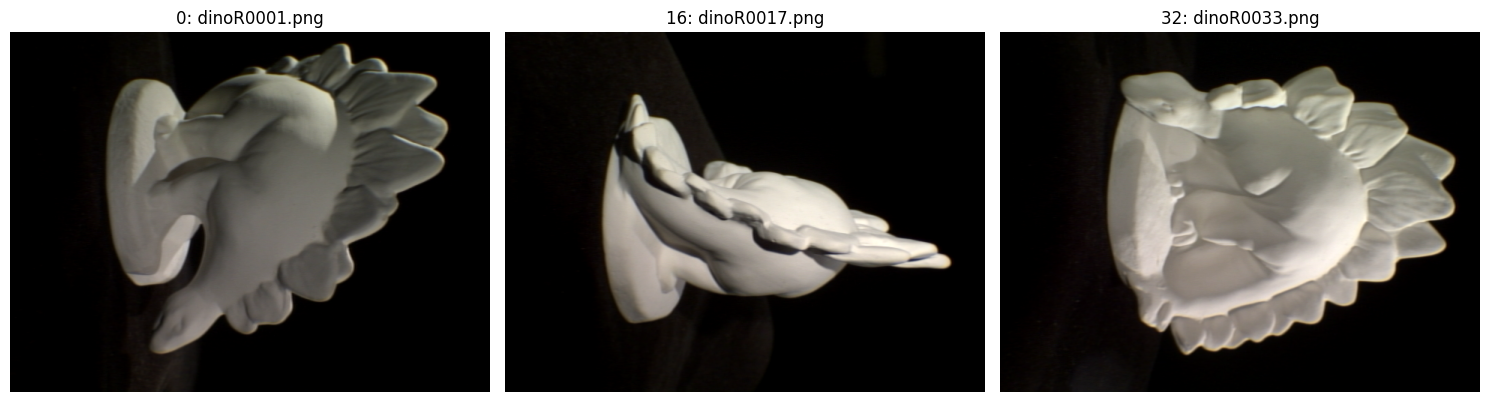

Extract RootSIFT: 100%|██████████| 48/48 [00:01<00:00, 33.35it/s]


Feature count stats | min=344 | median=509 | max=730


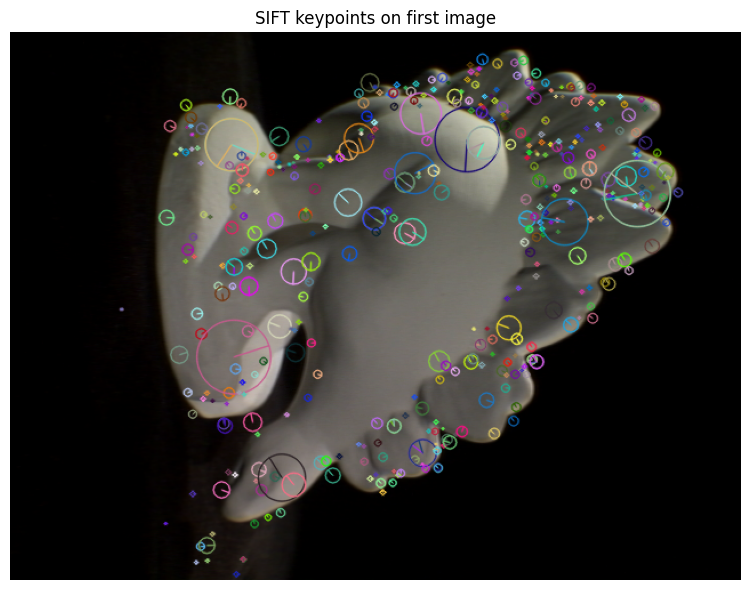

Pair matching + F-RANSAC: 100%|██████████| 1128/1128 [00:02<00:00, 436.55it/s]


Valid pairs: 201
Images participating in valid pairs: 48 / 48
Images without valid pair: []
Number of tracks: 3121
Track length stats | min=2 | median=3 | max=22
Initial K =
 [[768.   0. 320.]
 [  0. 768. 240.]
 [  0.   0.   1.]]
Initial pair = (28, 29) | inliers = 391
Initial 3D points from seed + extra triangulation: 357 | newly added = 20
[REGISTERED] image 21 | PnP inliers = 22 | registered = 3/48 | points = 366 | new points = 9
[REGISTERED] image 22 | PnP inliers = 27 | registered = 4/48 | points = 394 | new points = 28
[REGISTERED] image 23 | PnP inliers = 56 | registered = 5/48 | points = 450 | new points = 56
[REGISTERED] image 24 | PnP inliers = 113 | registered = 6/48 | points = 502 | new points = 52
[REGISTERED] image 25 | PnP inliers = 176 | registered = 7/48 | points = 541 | new points = 39
[REGISTERED] image 26 | PnP inliers = 222 | registered = 8/48 | points = 614 | new points = 73
[REGISTERED] image 27 | PnP inliers = 307 | registered = 9/48 | points = 666 | new points 

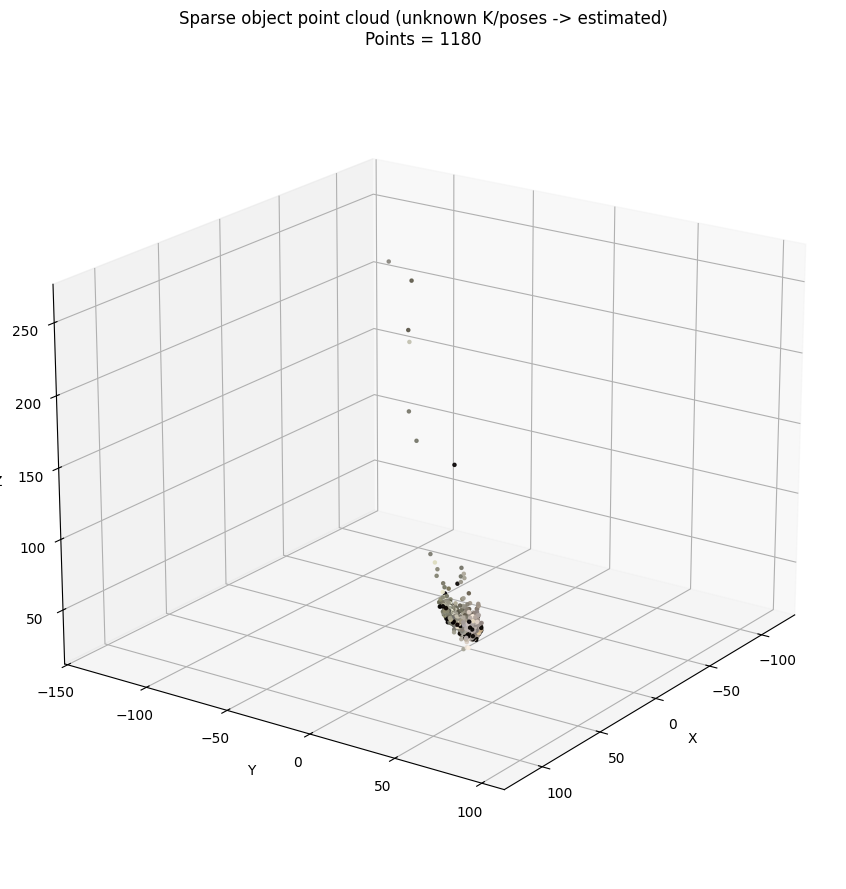

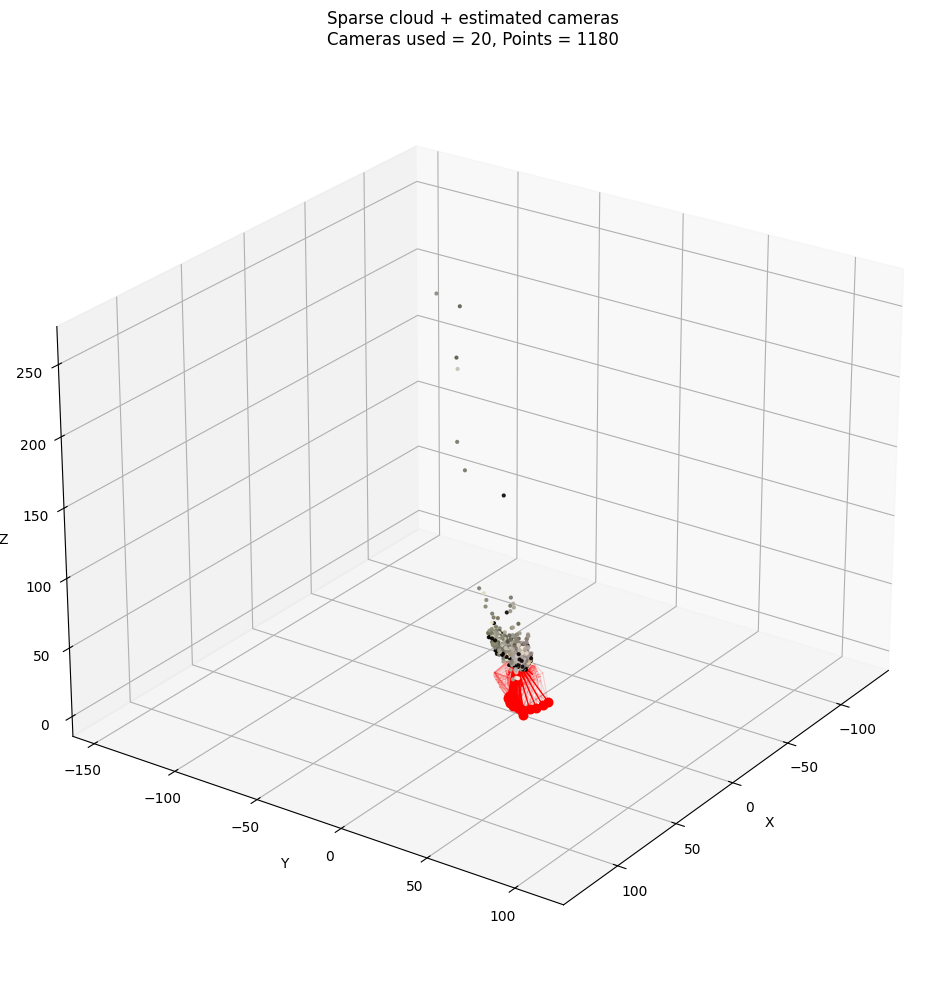

[WARN] plotly is not installed; skip interactive HTML.
[WARN] plotly is not installed; skip interactive HTML.


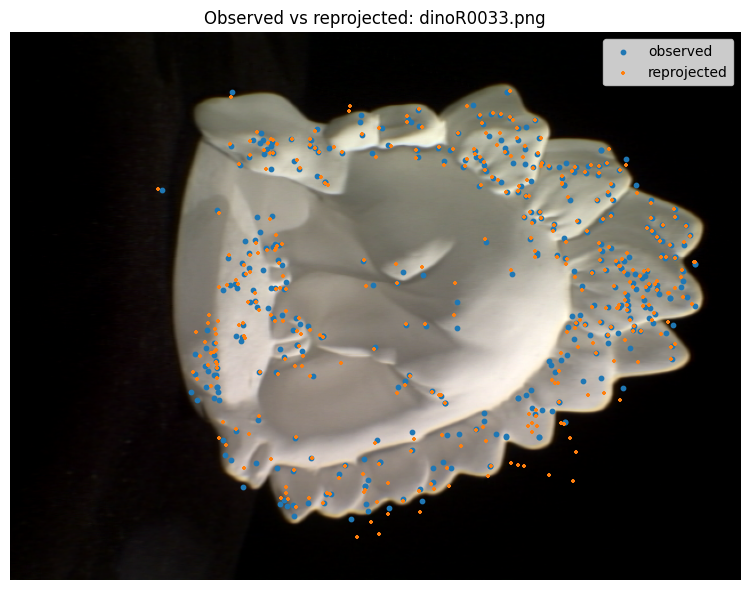

In [12]:
results = run_incremental_sfm_unknown_K_pose()
